# 2026-09-08: EW(Hα) versus corrected emission-line fluxes and ratios

This notebook tests whether EW(Hα) shows a scaling relation with six corrected emission-line fluxes and six corrected line ratios in the current `further` spaxel products.

The analysis uses one common detection mask: **all six fitted (uncorrected) line fluxes must be strictly `> 20` and each fitted `flux/error` must be strictly `> 3` in the same spaxel**. Corrected fluxes are then used for every plotted flux and ratio. The product calls the blue [S II] component `SII6716`; this is the component referred to as SII6712 in the request.

Filled circles mark the established star-forming selection: finite stored `HA6562_FLUX_CORR_HII`, `PROXY_EWHA > 6 Å`, and finite intrinsic Hα dispersion `< 45 km s⁻¹`, where $\sigma_{\rm int}=\sqrt{\sigma_{\rm obs}^2-\sigma_{\rm corr}^2}$ is defined only for positive variance difference. Open circles are all other spaxels that pass the common six-line detection mask.

## Analysis plan

1. Discover current `v3tk_v7.6.8/<galaxy>/` gas and EW products and require every named HDU.
2. Apply the simultaneous six-line detection cut to fitted fluxes and fitted flux errors.
3. Retain positive finite EW and corrected fluxes, derive corrected ratios, and label (without filtering to) the established SF subset.
4. Plot all 6 flux relations and all 6 ratio relations in log–log space. Points are deterministically thinned only for display; statistics use every selected spaxel.
5. Report descriptive pooled Spearman coefficients and galaxy-level distributions of Spearman $\rho$ and log–log slopes. The galaxy-level summary is the inferential unit; pooled-spaxel p-values are intentionally not reported.

In [1]:
from __future__ import annotations

import os
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.io import fits
from IPython.display import display
from scipy import stats

PROJECT_ROOT = Path.cwd().resolve()
RUN_DIR = PROJECT_ROOT / 'v3tk_v7.6.8'
EW_HDU = 'PROXY_EWHA'
FLUX_MIN = 20.0
SNR_MIN = 3.0
EW_SF_MIN = 6.0
HA_SIGMA_MAX = 45.0
MIN_GALAXY_POINTS = 30
MAX_PLOT_POINTS_PER_GALAXY_CLASS = 2000
PLOT_RANDOM_SEED = 20260908

LINES = {
    'hb': {'base': 'HB4861', 'label': r'H$\beta$'},
    'ha': {'base': 'HA6562', 'label': r'H$\alpha$'},
    'oiii': {'base': 'OIII5006', 'label': r'[O III] $\lambda5007$'},
    'nii': {'base': 'NII6583', 'label': r'[N II] $\lambda6583$'},
    'sii6716': {'base': 'SII6716', 'label': r'[S II] $\lambda6716$'},
    'sii6730': {'base': 'SII6730', 'label': r'[S II] $\lambda6731$'},
}
RATIOS = {
    'oiii_hb': {'label': r'[O III]/H$\beta$', 'numerator': ('oiii',), 'denominator': ('hb',)},
    'nii_ha': {'label': r'[N II]/H$\alpha$', 'numerator': ('nii',), 'denominator': ('ha',)},
    'sii_ha': {'label': r'([S II]6716+6731)/H$\alpha$', 'numerator': ('sii6716', 'sii6730'), 'denominator': ('ha',)},
    'sii6716_ha': {'label': r'[S II]6716/H$\alpha$', 'numerator': ('sii6716',), 'denominator': ('ha',)},
    'sii6730_ha': {'label': r'[S II]6731/H$\alpha$', 'numerator': ('sii6730',), 'denominator': ('ha',)},
    'nii_sii': {'label': r'[N II]/([S II]6716+6731)', 'numerator': ('nii',), 'denominator': ('sii6716', 'sii6730')},
}

mpl.rcParams.update({'figure.dpi': 120, 'font.size': 10, 'axes.grid': True, 'grid.alpha': 0.2})
print(f'Project root: {PROJECT_ROOT}')
print(f'Run directory: {RUN_DIR}')
print(f'Common detection: all six lines flux > {FLUX_MIN:g} and flux/error > {SNR_MIN:g}')

Project root: /Users/Igniz/Desktop/ICRAR/further
Run directory: /Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8
Common detection: all six lines flux > 20 and flux/error > 3


In [2]:
def first_existing(*paths: Path) -> Path | None:
    return next((path for path in paths if path.exists()), None)


def with_gzip(path: Path) -> tuple[Path, Path]:
    return path, Path(str(path) + '.gz')


def fits_hdu_names(path: Path | None) -> set[str]:
    if path is None:
        return set()
    with fits.open(path, memmap=True) as hdul:
        return {hdu.name.upper() for hdu in hdul}


def align_map_to_shape(data, target_shape, *, label, max_delta=2):
    arr = np.asarray(data, dtype=float)
    target_shape = tuple(target_shape)
    if arr.shape == target_shape:
        return arr
    if arr.ndim != len(target_shape) or any(abs(a - b) > max_delta for a, b in zip(arr.shape, target_shape)):
        raise ValueError(f'{label}: cannot align {arr.shape} to {target_shape}')
    aligned = np.full(target_shape, np.nan, dtype=float)
    overlap = tuple(min(a, b) for a, b in zip(arr.shape, target_shape))
    slices = tuple(slice(0, n) for n in overlap)
    aligned[slices] = arr[slices]
    print(f'  {label}: aligned {arr.shape} -> {target_shape}; overlap={overlap}')
    return aligned


REQUIRED_GAS_HDUS = {'HA6562_SIGMA', 'HA6562_SIGMA_CORR', 'HA6562_FLUX_CORR_HII'}
for cfg in LINES.values():
    base = cfg['base']
    REQUIRED_GAS_HDUS.update({f'{base}_FLUX', f'{base}_FLUX_ERR', f'{base}_FLUX_CORR'})


def discover_products(run_dir=RUN_DIR):
    rows = []
    for folder in sorted(path for path in run_dir.iterdir() if path.is_dir()):
        galaxy = folder.name
        gas_path = first_existing(
            *with_gzip(folder / f'{galaxy}_gas_bin_maps_further.fits'),
            *with_gzip(folder / f'{galaxy}_gas_BIN_maps_further.fits'),
            *with_gzip(folder / f'{galaxy}_gas_bin_maps.fits'),
            *with_gzip(folder / f'{galaxy}_gas_BIN_maps.fits'),
        )
        ew_path = first_existing(
            *with_gzip(folder / f'{galaxy}_proxy_EW_maps_further.fits'),
            *with_gzip(folder / f'{galaxy}_proxy_EW_maps.fits'),
        )
        gas_hdus = fits_hdu_names(gas_path)
        ew_hdus = fits_hdu_names(ew_path)
        missing = sorted(REQUIRED_GAS_HDUS - gas_hdus)
        rows.append({'galaxy': galaxy, 'gas_path': gas_path, 'ew_path': ew_path,
                     'ready': not missing and EW_HDU in ew_hdus,
                     'missing_gas_hdus': ', '.join(missing), 'has_ew': EW_HDU in ew_hdus})
    return pd.DataFrame(rows).set_index('galaxy', drop=False)


PRODUCTS = discover_products()
requested = [x.strip() for x in os.getenv('MAUVE_GALAXIES', '').split(',') if x.strip()]
if requested:
    unknown = sorted(set(requested) - set(PRODUCTS.index))
    if unknown:
        raise KeyError(f'Unknown MAUVE_GALAXIES: {unknown}')
    SELECTED_GALAXIES = [g for g in requested if PRODUCTS.loc[g, 'ready']]
else:
    SELECTED_GALAXIES = PRODUCTS.index[PRODUCTS['ready']].tolist()
print(f'Discovered: {len(PRODUCTS)} galaxies; product-ready: {len(SELECTED_GALAXIES)}')
display(PRODUCTS[['ready', 'has_ew', 'missing_gas_hdus', 'gas_path', 'ew_path']])

Discovered: 38 galaxies; product-ready: 35


,ready,has_ew,missing_gas_hdus,gas_path,ew_path
galaxy,,,,,
IC3392,True,True,,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...
NGC4064,True,True,,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...
NGC4189,True,True,,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...
NGC4192,True,True,,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...
NGC4222,True,True,,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...
NGC4254,True,True,,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...
NGC4293,True,True,,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...
NGC4294,True,True,,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...
NGC4298,True,True,,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...


## Build the common detected-spaxel sample

Detection is evaluated on the fitted `*_FLUX` and `*_FLUX_ERR` maps, before dust correction. This avoids defining detectability from the correction itself. All plotted values come from `*_FLUX_CORR`. A positive finite corrected value is required because the figures use logarithmic axes. The SF flag is a label within the common detected sample, not an additional sample cut.

In [3]:
def sum_columns(columns, keys):
    return np.sum([columns[key] for key in keys], axis=0)


def load_galaxy_sample(galaxy):
    row = PRODUCTS.loc[galaxy]
    with fits.open(row['gas_path'], memmap=True) as hdul:
        raw = {key: np.asarray(hdul[f"{cfg['base']}_FLUX"].data, dtype=float) for key, cfg in LINES.items()}
        raw_err = {key: np.asarray(hdul[f"{cfg['base']}_FLUX_ERR"].data, dtype=float) for key, cfg in LINES.items()}
        corrected = {key: np.asarray(hdul[f"{cfg['base']}_FLUX_CORR"].data, dtype=float) for key, cfg in LINES.items()}
        hii_reference = np.asarray(hdul['HA6562_FLUX_CORR_HII'].data, dtype=float)
        sigma_obs = np.asarray(hdul['HA6562_SIGMA'].data, dtype=float)
        sigma_corr = np.asarray(hdul['HA6562_SIGMA_CORR'].data, dtype=float)

    target_shape = raw['ha'].shape
    for group_name, group in [('raw', raw), ('error', raw_err), ('corrected', corrected)]:
        for key in group:
            group[key] = align_map_to_shape(group[key], target_shape, label=f'{galaxy} {group_name} {key}')
    hii_reference = align_map_to_shape(hii_reference, target_shape, label=f'{galaxy} HII reference')
    sigma_obs = align_map_to_shape(sigma_obs, target_shape, label=f'{galaxy} HA sigma')
    sigma_corr = align_map_to_shape(sigma_corr, target_shape, label=f'{galaxy} HA sigma correction')
    with fits.open(row['ew_path'], memmap=True) as hdul:
        ew = align_map_to_shape(hdul[EW_HDU].data, target_shape, label=f'{galaxy} {EW_HDU}')

    detected = np.ones(target_shape, dtype=bool)
    for key in LINES:
        signal, error = raw[key], raw_err[key]
        detected &= (np.isfinite(signal) & np.isfinite(error) & (error > 0)
                     & (signal > FLUX_MIN) & ((signal / error) > SNR_MIN))
        detected &= np.isfinite(corrected[key]) & (corrected[key] > 0)
    detected &= np.isfinite(ew) & (ew > 0)

    sigma2 = sigma_obs**2 - sigma_corr**2
    intrinsic_sigma = np.full(target_shape, np.nan)
    sigma_ok = np.isfinite(sigma2) & (sigma2 > 0)
    intrinsic_sigma[sigma_ok] = np.sqrt(sigma2[sigma_ok])
    is_sf = (np.isfinite(hii_reference) & (ew > EW_SF_MIN)
             & np.isfinite(intrinsic_sigma) & (intrinsic_sigma < HA_SIGMA_MAX))

    data = {'galaxy': np.repeat(galaxy, np.count_nonzero(detected)),
            'ew_ha': ew[detected], 'is_sf': is_sf[detected]}
    for key in LINES:
        data[key] = corrected[key][detected]
    frame = pd.DataFrame(data)
    for key, cfg in RATIOS.items():
        numerator = sum_columns(frame, cfg['numerator'])
        denominator = sum_columns(frame, cfg['denominator'])
        frame[key] = numerator / denominator
    return frame, {'galaxy': galaxy, 'map_spaxels': int(np.prod(target_shape)),
                   'all_line_detected': int(np.count_nonzero(detected)),
                   'detected_sf': int(np.count_nonzero(detected & is_sf)),
                   'detected_other': int(np.count_nonzero(detected & ~is_sf))}


pieces, coverage_rows = [], []
for galaxy in SELECTED_GALAXIES:
    frame, coverage = load_galaxy_sample(galaxy)
    pieces.append(frame)
    coverage_rows.append(coverage)
DATA = pd.concat(pieces, ignore_index=True) if pieces else pd.DataFrame()
COVERAGE = pd.DataFrame(coverage_rows).set_index('galaxy')
display(COVERAGE)
print(f'Total common-mask spaxels: {len(DATA):,}')
print(f"SF: {DATA['is_sf'].sum():,}; other: {(~DATA['is_sf']).sum():,}")

,map_spaxels,all_line_detected,detected_sf,detected_other
galaxy,,,,
IC3392,191406,17434,12674,4760
NGC4064,376390,28063,3270,24793
NGC4189,190762,94898,73241,21657
NGC4192,1778868,303450,113134,190316
NGC4222,665720,46320,33495,12825
NGC4254,1204280,685895,556843,129052
NGC4293,491036,35843,424,35419
NGC4294,375921,104425,67248,37177
NGC4298,1036790,96354,77752,18602


Total common-mask spaxels: 4,414,820
SF: 2,435,560; other: 1,979,260


## Galaxy-level scaling summaries

Each relation is evaluated in $\log_{10}$–$\log_{10}$ space. `pooled_rho` is descriptive only. The principal summary is the median and interquartile range of per-galaxy Spearman coefficients and slopes, plus an exact two-sided sign test asking whether positive and negative galaxy correlations are balanced. This respects galaxies—not individual spaxels—as the independent units. Results are shown separately for SF and other detected spaxels.

In [4]:
RELATIONS = ({key: {'label': cfg['label'], 'kind': 'corrected flux'} for key, cfg in LINES.items()}
             | {key: {'label': cfg['label'], 'kind': 'corrected ratio'} for key, cfg in RATIOS.items()})


def relation_summary(frame, ykey, sf_value):
    subset = frame.loc[frame['is_sf'].eq(sf_value), ['galaxy', 'ew_ha', ykey]].copy()
    subset = subset[np.isfinite(subset['ew_ha']) & (subset['ew_ha'] > 0)
                    & np.isfinite(subset[ykey]) & (subset[ykey] > 0)]
    x_all, y_all = np.log10(subset['ew_ha']), np.log10(subset[ykey])
    pooled_rho = stats.spearmanr(x_all, y_all).statistic if len(subset) >= 3 else np.nan
    galaxy_rows = []
    for galaxy, group in subset.groupby('galaxy'):
        if len(group) < MIN_GALAXY_POINTS:
            continue
        x, y = np.log10(group['ew_ha'].to_numpy()), np.log10(group[ykey].to_numpy())
        if np.unique(x).size < 2 or np.unique(y).size < 2:
            continue
        galaxy_rows.append({'galaxy': galaxy, 'n': len(group),
                            'rho': stats.spearmanr(x, y).statistic,
                            'slope': stats.linregress(x, y).slope})
    per_galaxy = pd.DataFrame(galaxy_rows)
    if per_galaxy.empty:
        return {'n_spaxels': len(subset), 'n_galaxies': 0, 'pooled_rho': pooled_rho}
    nonzero = per_galaxy.loc[per_galaxy['rho'] != 0, 'rho']
    sign_p = stats.binomtest(int((nonzero > 0).sum()), len(nonzero), 0.5).pvalue if len(nonzero) else np.nan
    return {'n_spaxels': len(subset), 'n_galaxies': len(per_galaxy), 'pooled_rho': pooled_rho,
            'median_galaxy_rho': per_galaxy['rho'].median(),
            'rho_q25': per_galaxy['rho'].quantile(0.25), 'rho_q75': per_galaxy['rho'].quantile(0.75),
            'median_loglog_slope': per_galaxy['slope'].median(),
            'slope_q25': per_galaxy['slope'].quantile(0.25), 'slope_q75': per_galaxy['slope'].quantile(0.75),
            'positive_rho_galaxies': int((per_galaxy['rho'] > 0).sum()), 'sign_test_p': sign_p}


summary_rows = []
for ykey, cfg in RELATIONS.items():
    for sf_value, sample_label in [(True, 'SF'), (False, 'other')]:
        summary_rows.append({'relation': cfg['label'], 'quantity': cfg['kind'], 'sample': sample_label,
                             **relation_summary(DATA, ykey, sf_value)})
SUMMARY = pd.DataFrame(summary_rows).set_index(['quantity', 'relation', 'sample'])
display(SUMMARY.round(3))

n_spaxels  n_galaxies  \
quantity        relation                    sample                          
corrected flux  H$\beta$                    SF        2435560          35   
                                            other     1979260          35   
                H$\alpha$                   SF        2435560          35   
                                            other     1979260          35   
                [O III] $\lambda5007$       SF        2435560          35   
                                            other     1979260          35   
                [N II] $\lambda6583$        SF        2435560          35   
                                            other     1979260          35   
                [S II] $\lambda6716$        SF        2435560          35   
                                            other     1979260          35   
                [S II] $\lambda6731$        SF        2435560          35   
                                            other     1979260          35   
corrected ratio [O III]/H$\beta$            SF        2435560          35   
                                            other     1979260          35   
                [N II]/H$\alpha$            SF        2435560          35   
                                            other     1979260          35   
                ([S II]6716+6731)/H$\alpha$ SF        2435560          35   
                                            other     1979260          35   
                [S II]6716/H$\alpha$        SF        2435560          35   
                                            other     1979260          35   
                [S II]6731/H$\alpha$        SF        2435560          35   
                                            other     1979260          35   
                [N II]/([S II]6716+6731)    SF        2435560          35   
                                            other     1979260          35   

                                                    pooled_rho  \
quantity        relation                    sample               
corrected flux  H$\beta$                    SF           0.498   
                                            other        0.337   
                H$\alpha$                   SF           0.498   
                                            other        0.344   
                [O III] $\lambda5007$       SF           0.497   
                                            other        0.133   
                [N II] $\lambda6583$        SF           0.406   
                                            other        0.019   
                [S II] $\lambda6716$        SF           0.503   
                                            other        0.234   
                [S II] $\lambda6731$        SF           0.506   
                                            other        0.239   
corrected ratio [O III]/H$\beta$            SF          -0.122   
                                            other       -0.412   
                [N II]/H$\alpha$            SF          -0.503   
                                            other       -0.809   
                ([S II]6716+6731)/H$\alpha$ SF          -0.278   
                                            other       -0.486   
                [S II]6716/H$\alpha$        SF          -0.283   
                                            other       -0.477   
                [S II]6731/H$\alpha$        SF          -0.268   
                                            other       -0.464   
                [N II]/([S II]6716+6731)    SF          -0.016   
                                            other       -0.419   

                                                    median_galaxy_rho  \
quantity        relation                    sample                      
corrected flux  H$\beta$                    SF                  0.724   
                                            other               0.484   
                H$\alpha$               

In [5]:
def display_sample(frame):
    groups = []
    for _, group in frame.groupby(['galaxy', 'is_sf'], sort=True):
        n = min(len(group), MAX_PLOT_POINTS_PER_GALAXY_CLASS)
        groups.append(group.sample(n=n, random_state=PLOT_RANDOM_SEED) if len(group) > n else group)
    return pd.concat(groups, ignore_index=True) if groups else frame.copy()


PLOT_DATA = display_sample(DATA)
print(f'Plotting {len(PLOT_DATA):,} deterministic display points from {len(DATA):,} statistical spaxels')


def equal_galaxy_trend(frame, ykey, sf_value, n_bins=12):
    subset = frame[frame['is_sf'].eq(sf_value)]
    x = np.log10(subset['ew_ha'].to_numpy())
    finite = np.isfinite(x) & np.isfinite(subset[ykey].to_numpy()) & (subset[ykey].to_numpy() > 0)
    subset, x = subset.loc[finite].copy(), x[finite]
    if len(subset) < 10:
        return np.array([]), np.array([])
    edges = np.unique(np.nanquantile(x, np.linspace(0, 1, n_bins + 1)))
    subset['xbin'] = pd.cut(np.log10(subset['ew_ha']), edges, include_lowest=True, duplicates='drop')
    per_galaxy = subset.groupby(['galaxy', 'xbin'], observed=True).agg(
        x=('ew_ha', lambda v: np.nanmedian(np.log10(v))),
        y=(ykey, lambda v: np.nanmedian(np.log10(v))))
    trend = per_galaxy.groupby('xbin', observed=True).median(numeric_only=True)
    return trend['x'].to_numpy(), trend['y'].to_numpy()


def plot_relation_grid(keys, title):
    fig, axes = plt.subplots(2, 3, figsize=(16, 10), constrained_layout=True)
    for ax, ykey in zip(axes.flat, keys):
        for sf_value, face, edge, label, zorder in [
            (False, 'none', '#b05a2a', 'other detected', 1),
            (True, '#1769aa', '#1769aa', 'SF', 2),
        ]:
            part = PLOT_DATA[PLOT_DATA['is_sf'].eq(sf_value)]
            valid = np.isfinite(part[ykey]) & (part[ykey] > 0)
            ax.scatter(part.loc[valid, 'ew_ha'], part.loc[valid, ykey], s=8, marker='o',
                       facecolors=face, edgecolors=edge, linewidths=0.45, alpha=0.22,
                       rasterized=True, label=label, zorder=zorder)
            tx, ty = equal_galaxy_trend(DATA, ykey, sf_value)
            if tx.size:
                ax.plot(10**tx, 10**ty, color=edge, lw=2.4, zorder=3)
        ax.set_xscale('log'); ax.set_yscale('log')
        ax.set_xlabel(r'EW(H$\alpha$) [Å]')
        ylabel = RELATIONS[ykey]['label']
        if RELATIONS[ykey]['kind'] == 'corrected flux':
            ylabel += r' corrected flux [$10^{-20}$ erg s$^{-1}$ cm$^{-2}$]'
        ax.set_ylabel(ylabel)
        sf_stats = SUMMARY.loc[(RELATIONS[ykey]['kind'], RELATIONS[ykey]['label'], 'SF')]
        other_stats = SUMMARY.loc[(RELATIONS[ykey]['kind'], RELATIONS[ykey]['label'], 'other')]
        ax.set_title(f"median galaxy ρ: SF={sf_stats.get('median_galaxy_rho', np.nan):.2f}, "
                     f"other={other_stats.get('median_galaxy_rho', np.nan):.2f}")
    axes.flat[0].legend(loc='best', frameon=False, markerscale=2)
    fig.suptitle(title + '\nThick curves: equal-galaxy median trends; points: deterministic display subset', fontsize=14)
    return fig


Plotting 137,178 deterministic display points from 4,414,820 statistical spaxels


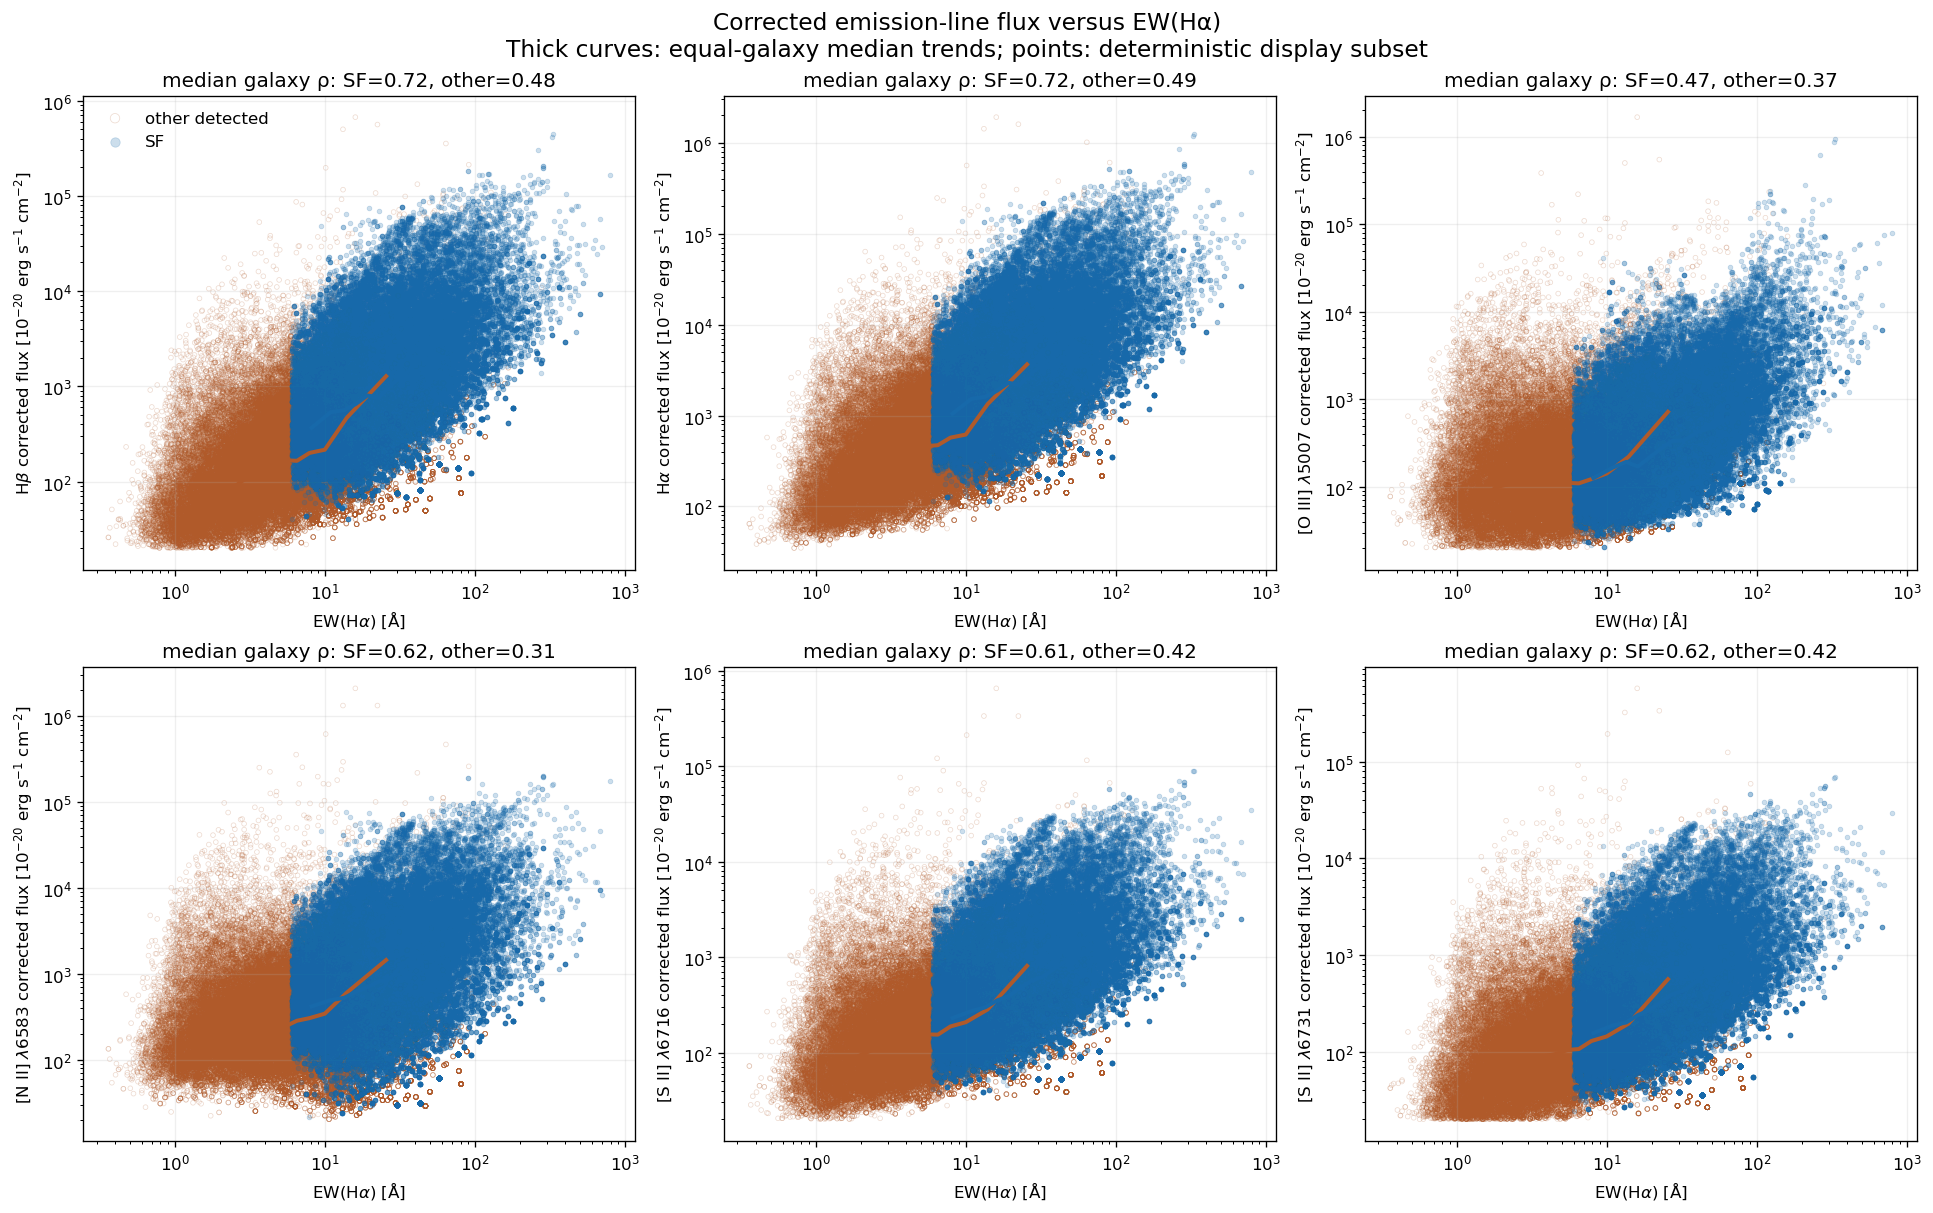

In [6]:
flux_figure = plot_relation_grid(list(LINES), 'Corrected emission-line flux versus EW(Hα)')
plt.show()

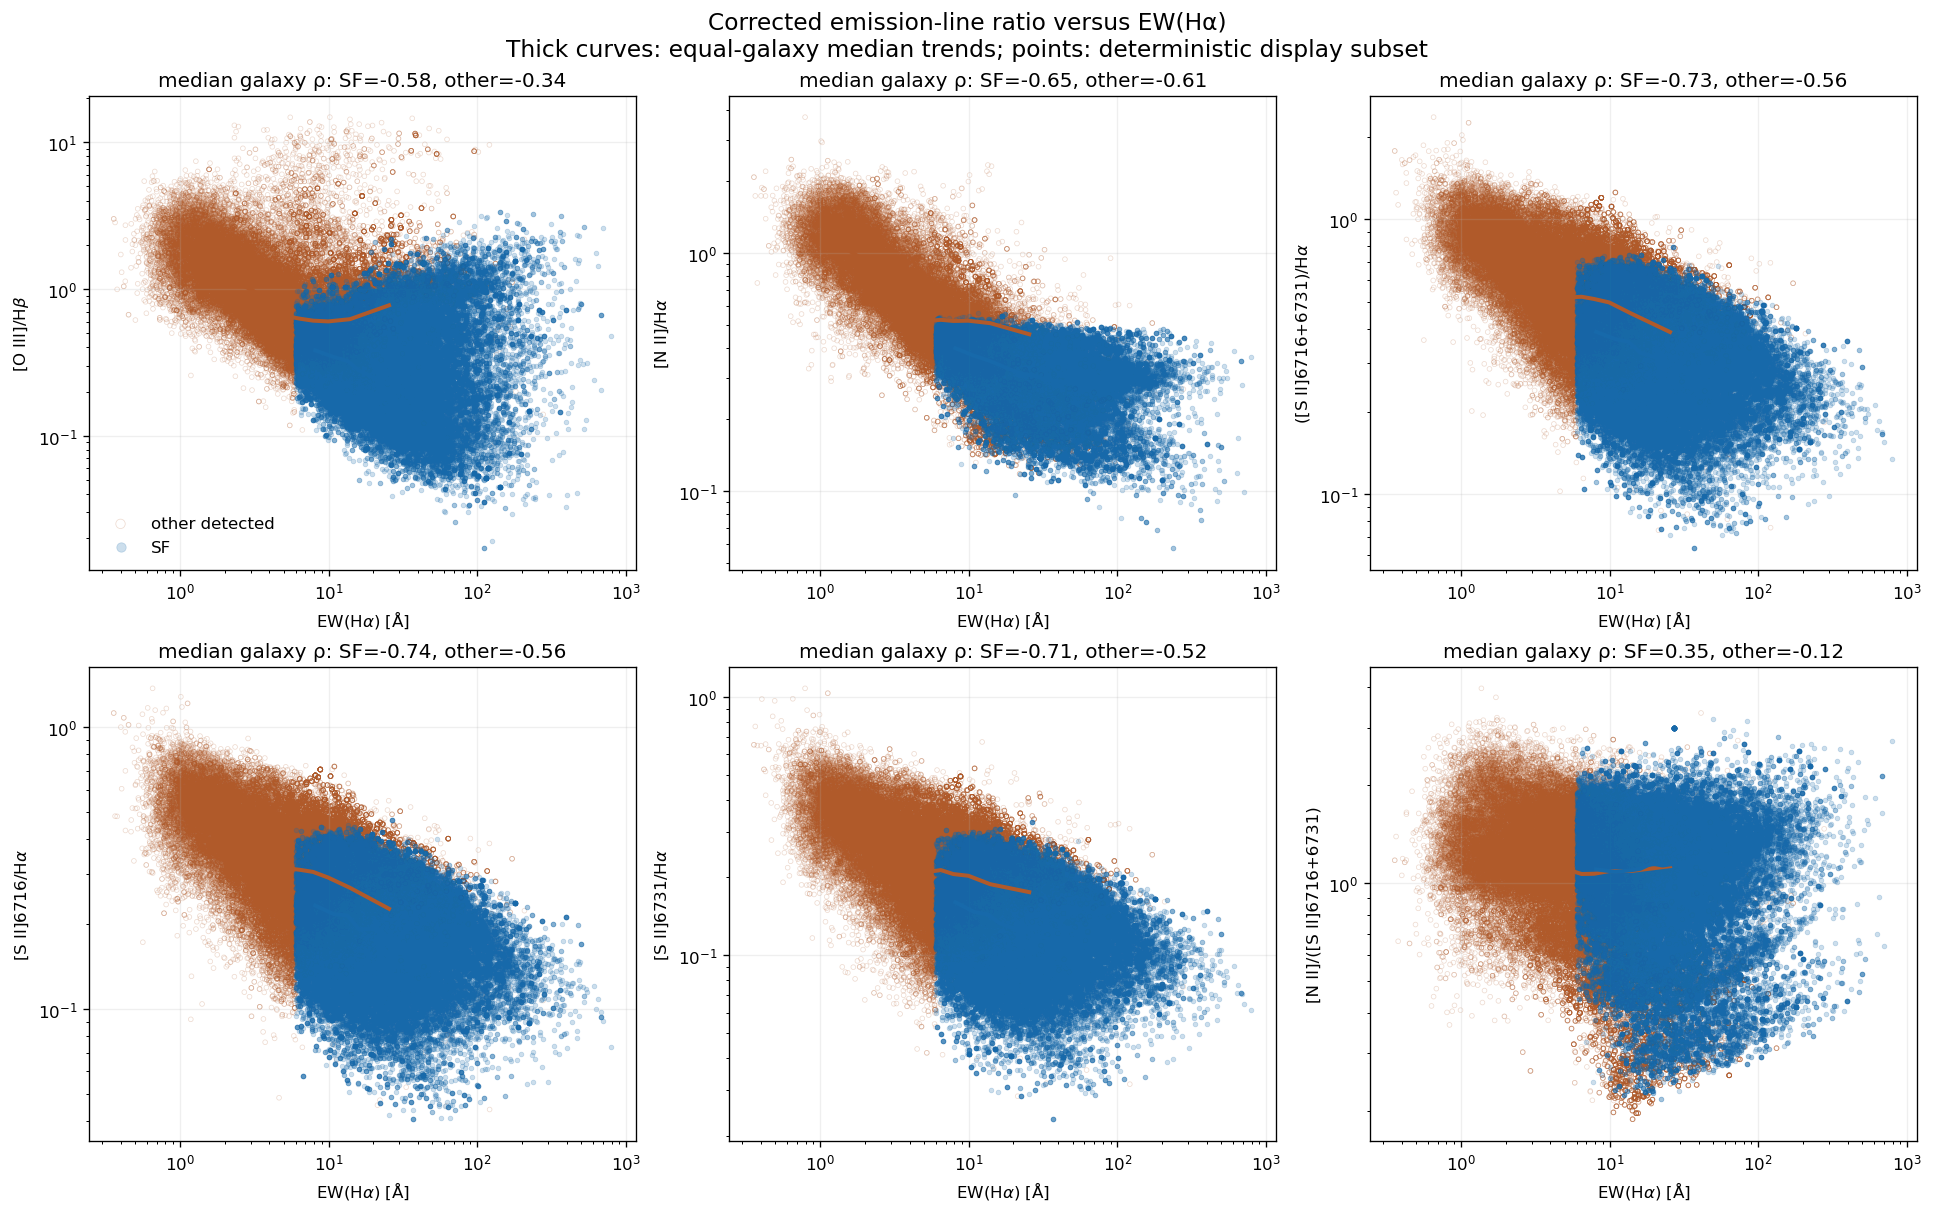

In [7]:
ratio_figure = plot_relation_grid(list(RATIOS), 'Corrected emission-line ratio versus EW(Hα)')
plt.show()

## Interpretation guide

A visually tight pooled sequence is not sufficient evidence for a universal scaling relation because spaxels within one galaxy are spatially correlated and galaxy-to-galaxy offsets can generate pooled structure. Give greatest weight to: (i) the median per-galaxy $\rho$ and its IQR, (ii) the fraction of galaxies with the same sign, (iii) the galaxy-level sign-test result, and (iv) whether the equal-galaxy median curve is monotonic. Flux–EW trends can also arise mechanically because EW is line flux divided by local continuum, so a flux relation does not by itself identify a new physical law. In these products the attenuation correction restores Hα/Hβ to the adopted intrinsic Balmer decrement (median 2.86), so the corrected Hα–EW and Hβ–EW relations are scaled copies and are not independent evidence. Ratios are less directly affected by absolute surface brightness, but remain sensitive to ionization, abundance, DIG/shocks, attenuation-correction systematics, and the common six-line selection boundary.

In [8]:
candidate = SUMMARY.reset_index().copy()
candidate['same_sign_fraction'] = candidate['positive_rho_galaxies'] / candidate['n_galaxies']
candidate['coherent_candidate'] = (candidate['median_galaxy_rho'].abs() >= 0.30) & (
    (candidate['same_sign_fraction'] >= 2/3) | (candidate['same_sign_fraction'] <= 1/3))
display(candidate.sort_values(['sample', 'coherent_candidate', 'median_galaxy_rho'], ascending=[True, False, False]).round(3))
print('coherent_candidate is a descriptive screening flag, not a calibrated discovery threshold.')

,quantity,relation,sample,n_spaxels,n_galaxies,pooled_rho,median_galaxy_rho,rho_q25,rho_q75,median_loglog_slope,slope_q25,slope_q75,positive_rho_galaxies,sign_test_p,same_sign_fraction,coherent_candidate
0,corrected flux,H$\beta$,SF,2435560,35,0.498,0.724,0.620,0.818,1.135,1.003,1.279,35,0.000,1.000,True
2,corrected flux,H$\alpha$,SF,2435560,35,0.498,0.724,0.620,0.818,1.135,1.003,1.279,35,0.000,1.000,True
6,corrected flux,[N II] $\lambda6583$,SF,2435560,35,0.406,0.625,0.539,0.765,0.972,0.822,1.060,35,0.000,1.000,True
10,corrected flux,[S II] $\lambda6731$,SF,2435560,35,0.506,0.619,0.558,0.729,0.859,0.754,0.988,35,0.000,1.000,True
8,corrected flux,[S II] $\lambda6716$,SF,2435560,35,0.503,0.615,0.552,0.726,0.854,0.746,0.972,35,0.000,1.000,True
4,corrected flux,[O III] $\lambda5007$,SF,2435560,35,0.497,0.475,0.363,0.694,0.768,0.482,1.040,35,0.000,1.000,True
22,corrected ratio,[N II]/([S II]6716+6731),SF,2435560,35,-0.016,0.349,0.211,0.587,0.085,0.074,0.134,33,0.000,0.943,True
12,corrected ratio,[O III]/H$\beta$,SF,2435560,35,-0.122,-0.580,-0.683,-0.041,-0.422,-0.582,-0.008,7,0.001,0.200,True
14,corrected ratio,[N II]/H$\alpha$,SF,2435560,35,-0.503,-0.651,-0.724,-0.535,-0.141,-0.195,-0.104,0,0.000,0.000,True
20,corrected ratio,[S II]6731/H$\alpha$,SF,2435560,35,-0.268,-0.707,-0.770,-0.585,-0.252,-0.307,-0.203,0,0.000,0.000,True


coherent_candidate is a descriptive screening flag, not a calibrated discovery threshold.
